In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

In [2]:
# DATA Preparation and Reading 

In [3]:
# Fetching last 5 years of nifty data 
nifty = yf.download("^NSEI", start="2020-01-01", end="2025-12-16")
nifty.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2020-01-01,12182.500000,12222.200195,12165.299805,12202.150391,304100
2020-01-02,12282.200195,12289.900391,12195.250000,12198.549805,407700
2020-01-03,12226.650391,12265.599609,12191.349609,12261.099609,428800
2020-01-06,11993.049805,12179.099609,11974.200195,12170.599609,396500
2020-01-07,12052.950195,12152.150391,12005.349609,12079.099609,447800


In [4]:
nifty.columns = nifty.columns.get_level_values(0)


In [5]:
nifty['Return'] = nifty['Close'].pct_change()


In [6]:
nifty['Return'] = nifty['Return'].clip(lower=-0.1, upper=0.1)

In [7]:
nifty['Volatility'] = nifty['Return'].rolling(window=30).std()
nifty.dropna(subset=['Volatility'], inplace=True)


In [8]:
nifty


Price,Close,High,Low,Open,Volume,Return,Volatility
Date,,,,,,,
2020-02-12,12201.200195,12231.750000,12144.299805,12151.000000,411700,0.007706,0.009315
2020-02-13,12174.650391,12225.650391,12139.799805,12219.549805,501200,-0.002176,0.009196
2020-02-14,12113.450195,12246.700195,12091.200195,12190.150391,622800,-0.005027,0.009204
2020-02-17,12045.799805,12159.599609,12037.000000,12131.799805,0,-0.005585,0.008559
2020-02-18,11992.500000,12030.750000,11908.049805,12028.250000,676900,-0.004425,0.008549
...,...,...,...,...,...,...,...
2025-12-09,25839.650391,25923.650391,25728.000000,25867.099609,276000,-0.004657,0.004925
2025-12-10,25758.000000,25947.650391,25734.550781,25864.050781,207900,-0.003160,0.004953
2025-12-11,25898.550781,25922.800781,25693.250000,25771.400391,206100,0.005457,0.004986


In [9]:
nifty.dropna(subset=['Close'], inplace=True)

In [10]:
nifty = nifty.fillna(method='ffill')

In [11]:
print(nifty.info())
print(nifty.describe())
print(nifty.isna().sum())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1445 entries, 2020-02-12 to 2025-12-15
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Close       1445 non-null   float64
 1   High        1445 non-null   float64
 2   Low         1445 non-null   float64
 3   Open        1445 non-null   float64
 4   Volume      1445 non-null   int64  
 5   Return      1445 non-null   float64
 6   Volatility  1445 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 90.3 KB
None
Price         Close          High           Low          Open        Volume  \
count   1445.000000   1445.000000   1445.000000   1445.000000  1.445000e+03   
mean   18628.950565  18725.938015  18525.465251  18637.893285  3.712325e+05   
std     4633.060925   4635.967409   4631.100936   4630.373106  1.939977e+05   
min     7610.250000   8036.950195   7511.100098   7735.149902  0.000000e+00   
25%    15799.099609  15870.799805  15726.400391  15807.5

In [12]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

train_size = int(len(nifty)*0.9)
train, test = nifty['Volatility'][:train_size], nifty['Volatility'][train_size:]

model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()
forecast = model_fit.forecast(steps=len(test))

rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)
print(f"ARIMA RMSE: {rmse:.6f}, MAE: {mae:.6f}")


D:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA RMSE: 0.007433, MAE: 0.007136


D:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [13]:
!pip install prophet

Defaulting to user installation because normal site-packages is not writeable


20:29:16 - cmdstanpy - INFO - Chain [1] start processing
20:29:17 - cmdstanpy - INFO - Chain [1] done processing


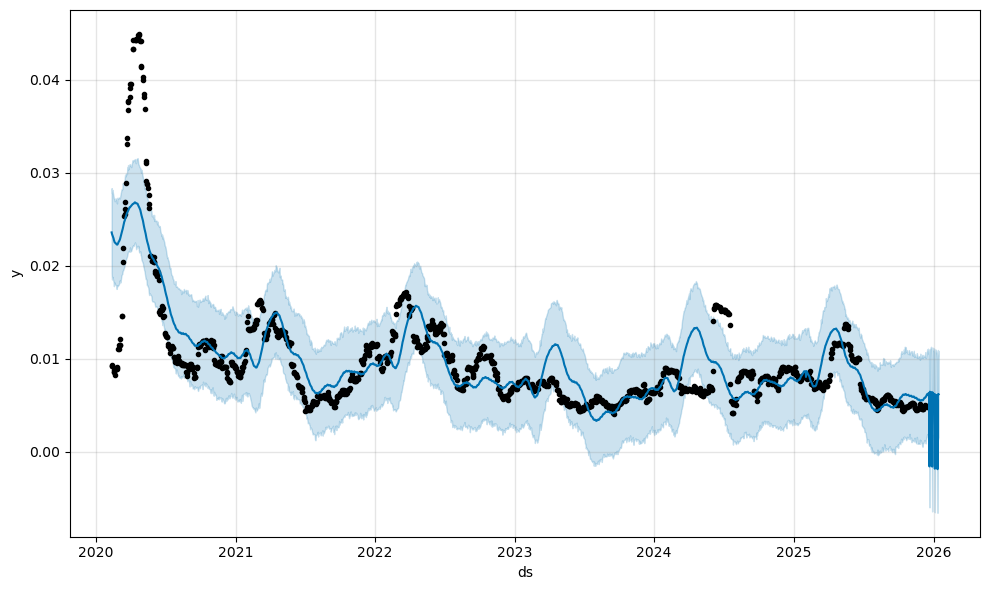

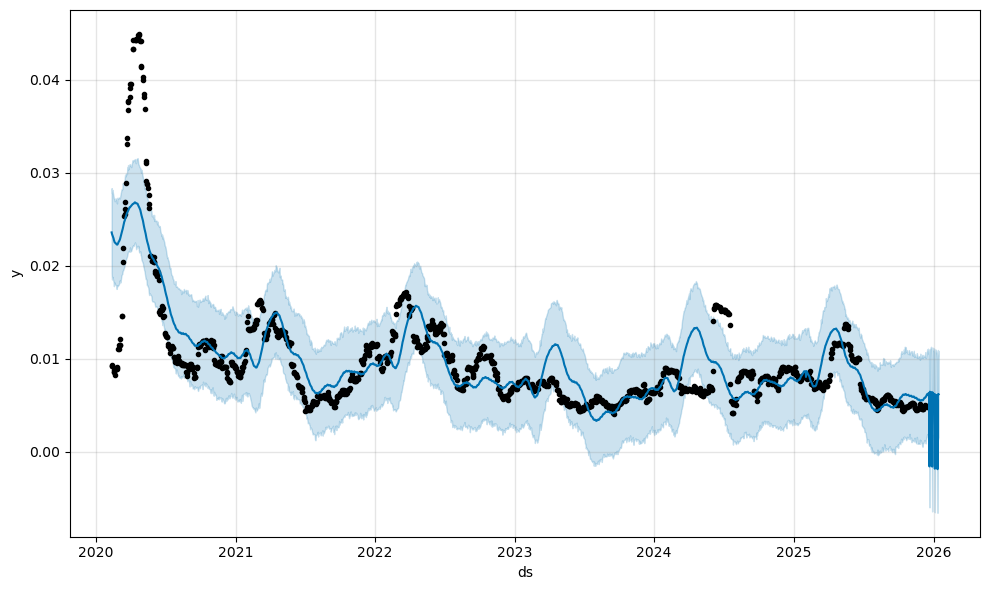

In [14]:
nifty = nifty.reset_index()  # brings 'Date' back as a column

from prophet import Prophet

df = nifty[['Date', 'Volatility']].rename(columns={'Date': 'ds', 'Volatility': 'y'})
model = Prophet()
model.fit(df)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

model.plot(forecast)


In [15]:
# Use latest volatility or predicted volatility safely
if isinstance(forecast, pd.DataFrame):
    # Prophet forecast case
    latest_vol = forecast['yhat'].tail(30)
elif isinstance(forecast, pd.Series):
    # ARIMA forecast case
    latest_vol = forecast.tail(30)
else:
    # Fallback to actual volatility if no forecast found
    latest_vol = nifty['Volatility'].tail(30)

# Now compute the mean volatility safely
mean_vol = np.mean(latest_vol.values)
print("Mean forecasted volatility:", round(mean_vol, 6))

# Normalize volatility to 0–100 Market Risk Score
nifty['Market_Risk_Score'] = (
    (nifty['Volatility'] - nifty['Volatility'].min()) /
    (nifty['Volatility'].max() - nifty['Volatility'].min())
) * 100

nifty['Market_Risk_Score'] = nifty['Market_Risk_Score'].round(2)
print("Latest Market Risk Score:", nifty['Market_Risk_Score'].iloc[-1])


Mean forecasted volatility: 0.005117
Latest Market Risk Score: 1.64


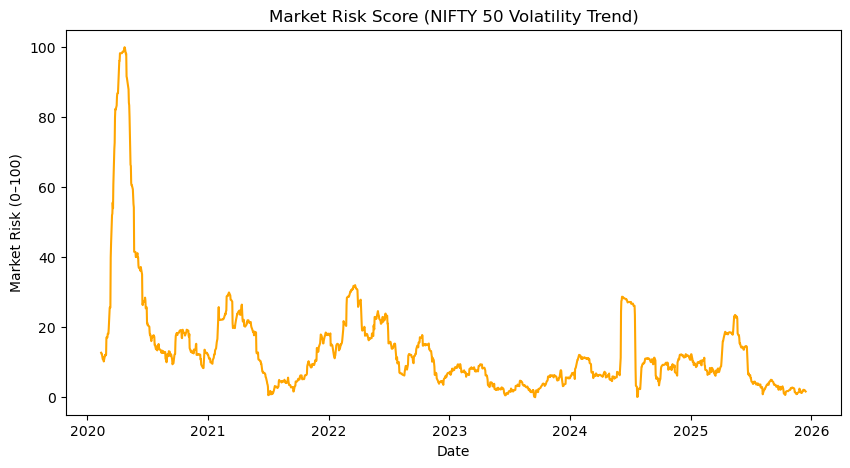

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(nifty['Date'], nifty['Market_Risk_Score'], color='orange')
plt.title('Market Risk Score (NIFTY 50 Volatility Trend)')
plt.xlabel('Date')
plt.ylabel('Market Risk (0–100)')
plt.show()



In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Forecast exactly len(test) steps ahead
forecast = model_fit.forecast(steps=len(test))

# Align lengths (if index mismatch occurs)
forecast = forecast[:len(test)]

rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)
print("RMSE:", round(rmse, 6))
print("MAE:", round(mae, 6))



RMSE: 0.007433
MAE: 0.007136


D:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [27]:
import joblib

# model = the full pipeline (preprocessing + classifier)
joblib.dump(model, "market_risk.pkl")

print("Model saved successfully!")

Model saved successfully!


In [20]:
nifty['Market_Risk_Score'] = (
    (nifty['Volatility'] - nifty['Volatility'].min())
    / (nifty['Volatility'].max() - nifty['Volatility'].min())
) * 100
nifty['Market_Risk_Score'] = nifty['Market_Risk_Score'].round(2)

# 4. Save for dashboard integration
nifty.to_csv("marketriskscore.csv", index=False)